In [43]:
import sys
sys.path.append('../../BasicDFIR/')
import yaml
from basicsr.archs.jit_arch import *
from basicsr.utils import *
from basicsr.metrics import *
from basicsr.models import build_model
from basicsr.data import build_dataloader, build_dataset
from basicsr.data.data_sampler import EnlargedSampler
from matplotlib import pyplot as plt
import numpy as np

### 定义模型

In [2]:
opt = yaml_load('../options/train/JiT/train_JiT_v2_1_swinflowir_B8_SRx2_P64_scratch.yml')
opt['path']['pretrain_network_g'] = '/8T2/Project/BasicDFIR/experiments/train_JiT_v2_1_swinflowir_B8_SRx2_P64_scratch_20260203_224443_309751/models/net_g_ema_360000.pth'
opt['strict_load_g'] = 'true'
opt['param_key_g']= 'params_ema'
opt['is_train']=0
opt['dist']= False
opt['rank'], opt['world_size']=0, 1
model = build_model(opt)

/home/ybb/miniconda3/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
torch.mean(list(model.net_g.parameters())[0]) #测试加载参数是否成功

tensor(-0.0003, device='cuda:0', grad_fn=<MeanBackward0>)

### 定义数据集

In [4]:
dataset_opt = opt['datasets']['val_1']
dataset_opt['phase'] ='val'
dataset_opt['scale'] =2
dataset_enlarge_ratio = 1
train_set = build_dataset(dataset_opt)
train_sampler = EnlargedSampler(train_set, opt['world_size'], opt['rank'], dataset_enlarge_ratio)
train_loader = build_dataloader(
    train_set,
    dataset_opt,
    num_gpu=opt['num_gpu'],
    dist=opt['dist'],
    sampler=train_sampler,
    seed=opt['manual_seed'])

In [75]:
iter_dataloader = iter(train_loader)

In [76]:
data = next(iter_dataloader)
lq, gt = data['lq'], data['gt']
print(data['lq_path'])

['/8T1/dataset/SRDataset/ImageSR/test/Set5/image_SRF_2/LR/img_003.png']


### 重写测试函数

In [46]:
def sample_image(lq, num_step=5, index=0, model=None, scale=1, direct=False):
    steps = num_step
    timesteps = torch.linspace(0.0, 1.0, steps + 1, device=model.device)
    b,c,h,w = lq.size()
    noise = torch.rand([b, c, h*scale, w*scale],device=model.device)# * self.noise_scale
    z = noise#lq:#[b,3,32,32], noise:[b,1,64,64]
    direct_sample_list = []
    for i in range(steps):
        t_curr = timesteps[i]
        t_next = timesteps[i + 1]
        t_curr = torch.full((b,), t_curr, device=model.device)
        t_next = torch.full((b,), t_next, device=model.device)
        direct_sample_list.append(_direct_sample(z=z, lq=lq, t=t_curr, t_next=t_next, model=model))
        z = direct_sample_list[index]
    return z.clamp(0, 1.0)

def _direct_sample(z, lq, t, t_next, model):
    x_pred = model.net_g(z, lq, t=t)
    return x_pred

In [47]:
def test(model, num_steps=5): 
    model.net_g.eval()
    test_model = model.net_g
    with torch.no_grad():
        img = model.lq_up
        print(img.shape)
        B, C, h, w = img.size()
        scale = model.scale
        net_opt = model.opt['network_g']
        hr_tile_h = net_opt.get('img_size', 256)
        hr_tile_w = hr_tile_h
        lr_tile_h = hr_tile_h // scale
        lr_tile_w = hr_tile_w // scale
        pad_h = (lr_tile_h - h % lr_tile_h) % lr_tile_h
        pad_w = (lr_tile_w - w % lr_tile_w) % lr_tile_w
        img_padded = F.pad(img, (0, pad_w, 0, pad_h), mode='reflect')
        _, _, H_pad, W_pad = img_padded.size()
        output_full = torch.zeros(B, C, H_pad * scale, W_pad * scale, device=model.device)
        for r in range(0, H_pad, lr_tile_h):
            for c in range(0, W_pad, lr_tile_w):
                lq_tile = img_padded[:, :, r: r + lr_tile_h, c: c + lr_tile_w]
                sr_tile = sample_image(lq_tile, num_step=5, model=model, scale=scale,direct=True)
                if sr_tile.dim() == 3:
                    sr_tile = sr_tile.unsqueeze(0)
                r_hr = r * scale
                c_hr = c * scale
                output_full[:, :, r_hr: r_hr + hr_tile_h, c_hr: c_hr + hr_tile_w] = sr_tile

        final_h = h * scale
        final_w = w * scale
        return output_full[:, :, :final_h, :final_w].clamp(0, 1)

### 模型推理

torch.Size([1, 3, 256, 256])


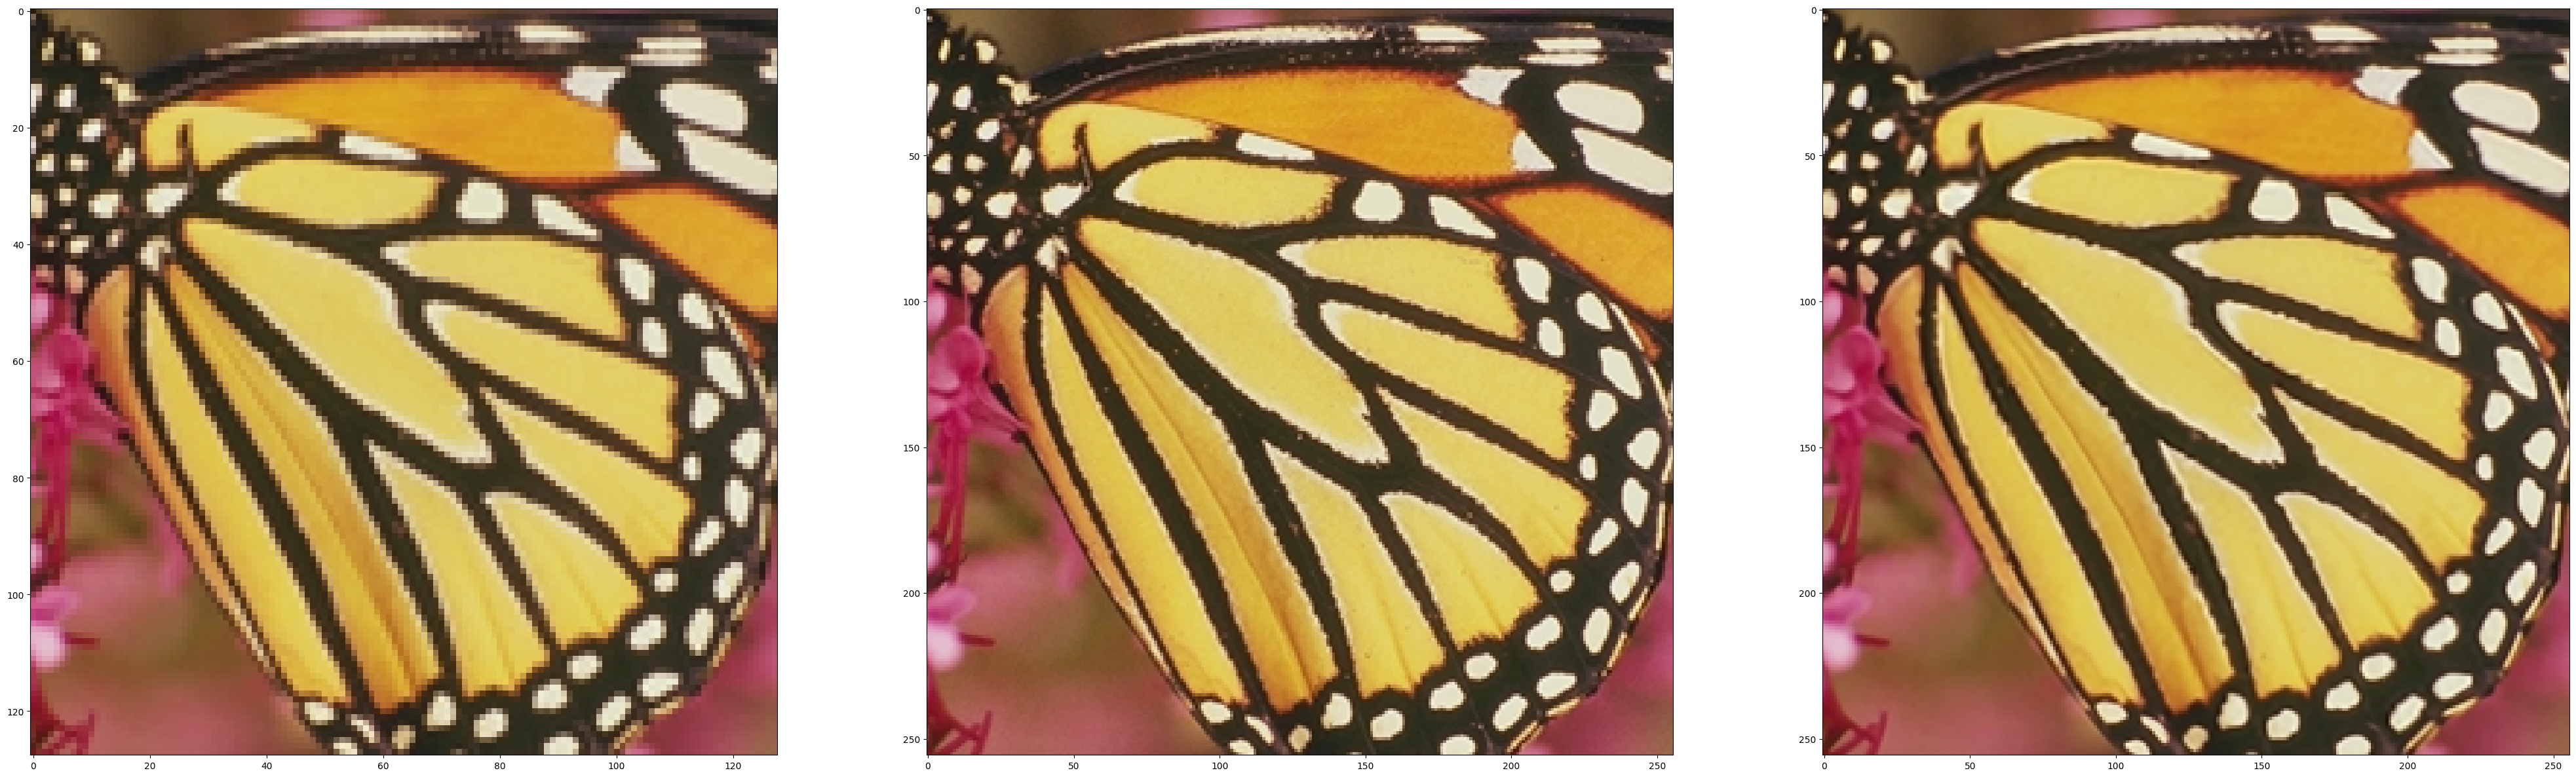

In [48]:
model.feed_data(data)
sr = test(model, num_steps=1)
plt.figure(figsize=(50,150))
plt.subplot(1,3,1)
plt.imshow(lq[0,...].cpu().permute(1,2,0))
plt.subplot(1,3,2)
plt.imshow(gt[0,...].permute(1,2,0))
plt.subplot(1,3,3)
plt.imshow(sr[0,...].cpu().permute(1,2,0))

In [49]:
calculate_psnr(tensor2img(sr), tensor2img(gt), crop_border=2)

np.float64(27.466451841507734)

In [85]:
import cv2
sr_swin_s=cv2.imread('./Set5/img_003_train_SwinIR_S_SRx2_scratch_B8_P32.png')
# gt = plt.imread('/8T1/dataset/SRDataset/ImageSR/test/Set5/HR/img_003.png')

In [86]:
calculate_psnr(tensor2img(sr), tensor2img(gt), crop_border=2)
calculate_psnr(sr_swin_s, tensor2img(gt), crop_border=2)

np.float64(33.42508959021154)

直接预测（第五步）的psnr：26.8968
直接预测（第一步）的psnr：27.4664
用swinir预测：33.4250


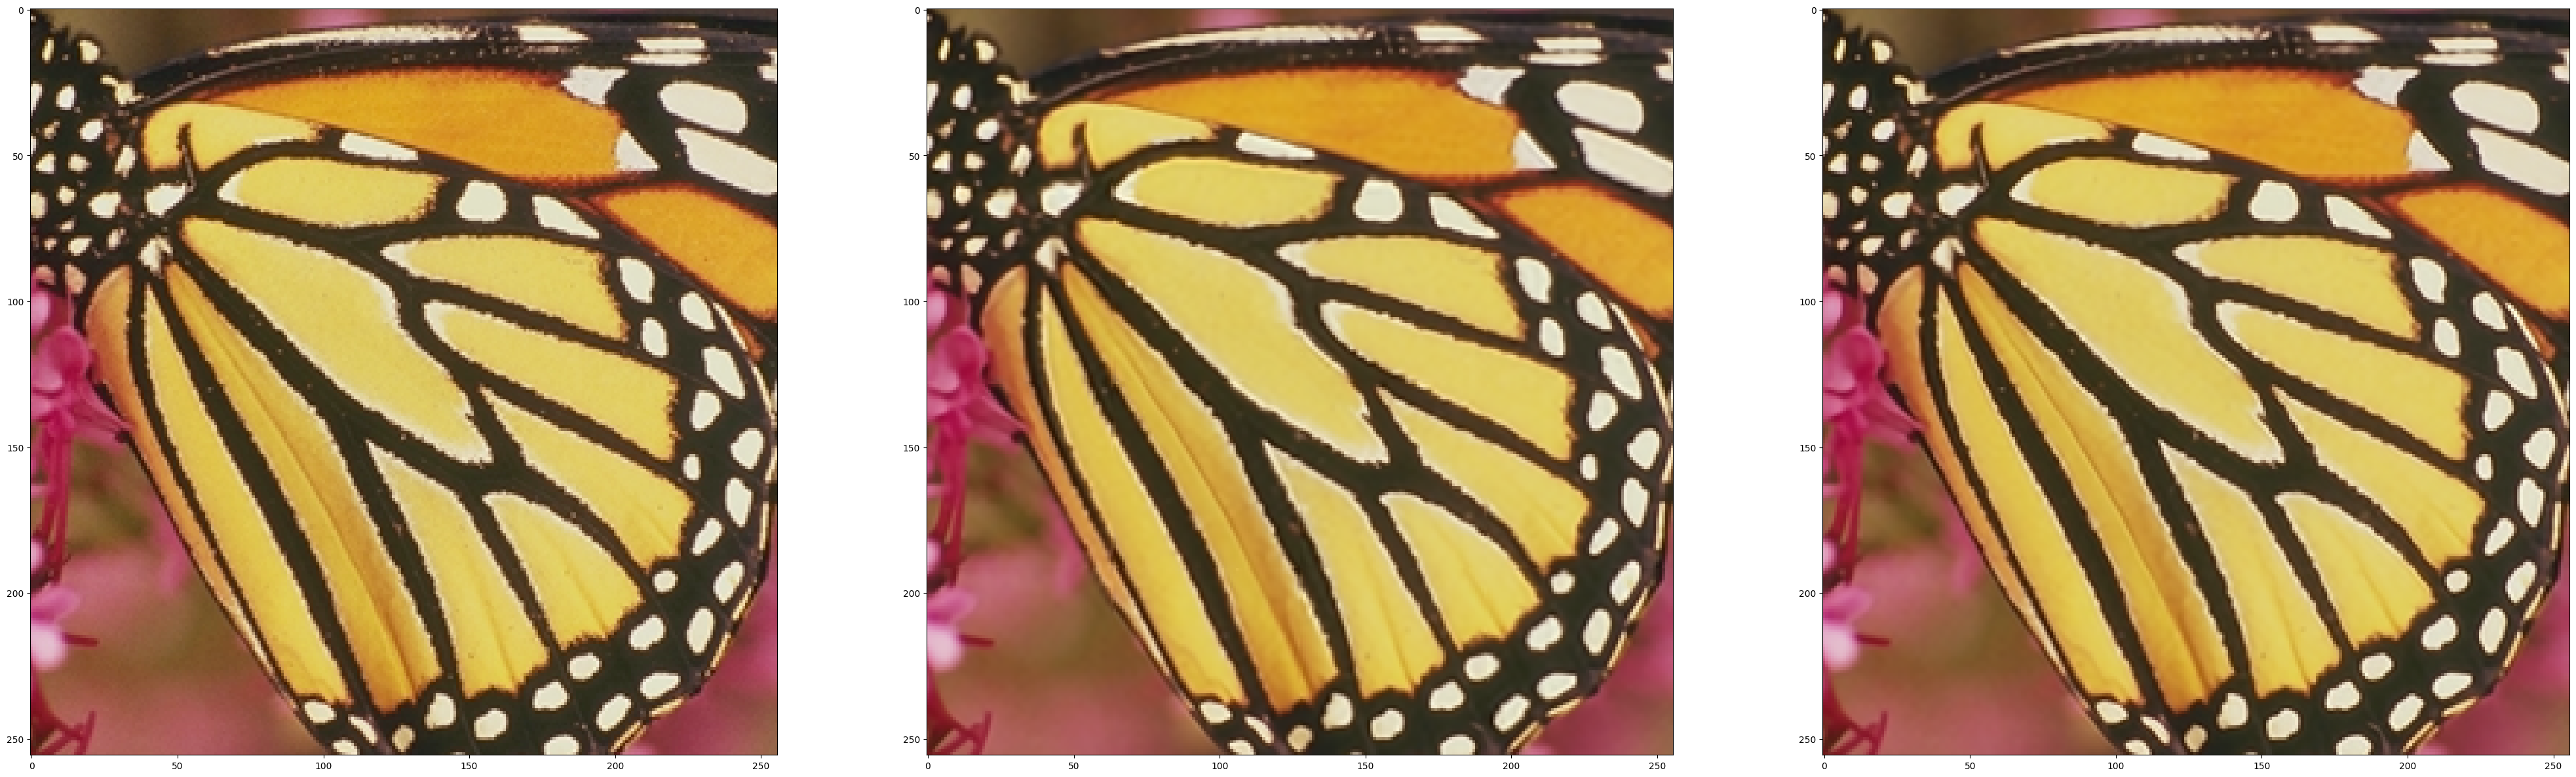

In [89]:
#视觉差异不明显
plt.figure(figsize=(50,150))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(tensor2img(gt), cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(tensor2img(sr), cv2.COLOR_BGR2RGB))
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(sr_swin_s, cv2.COLOR_BGR2RGB))

In [100]:
np.mean(tensor2img(gt)-tensor2img(sr),axis=2).shape

(256, 256)

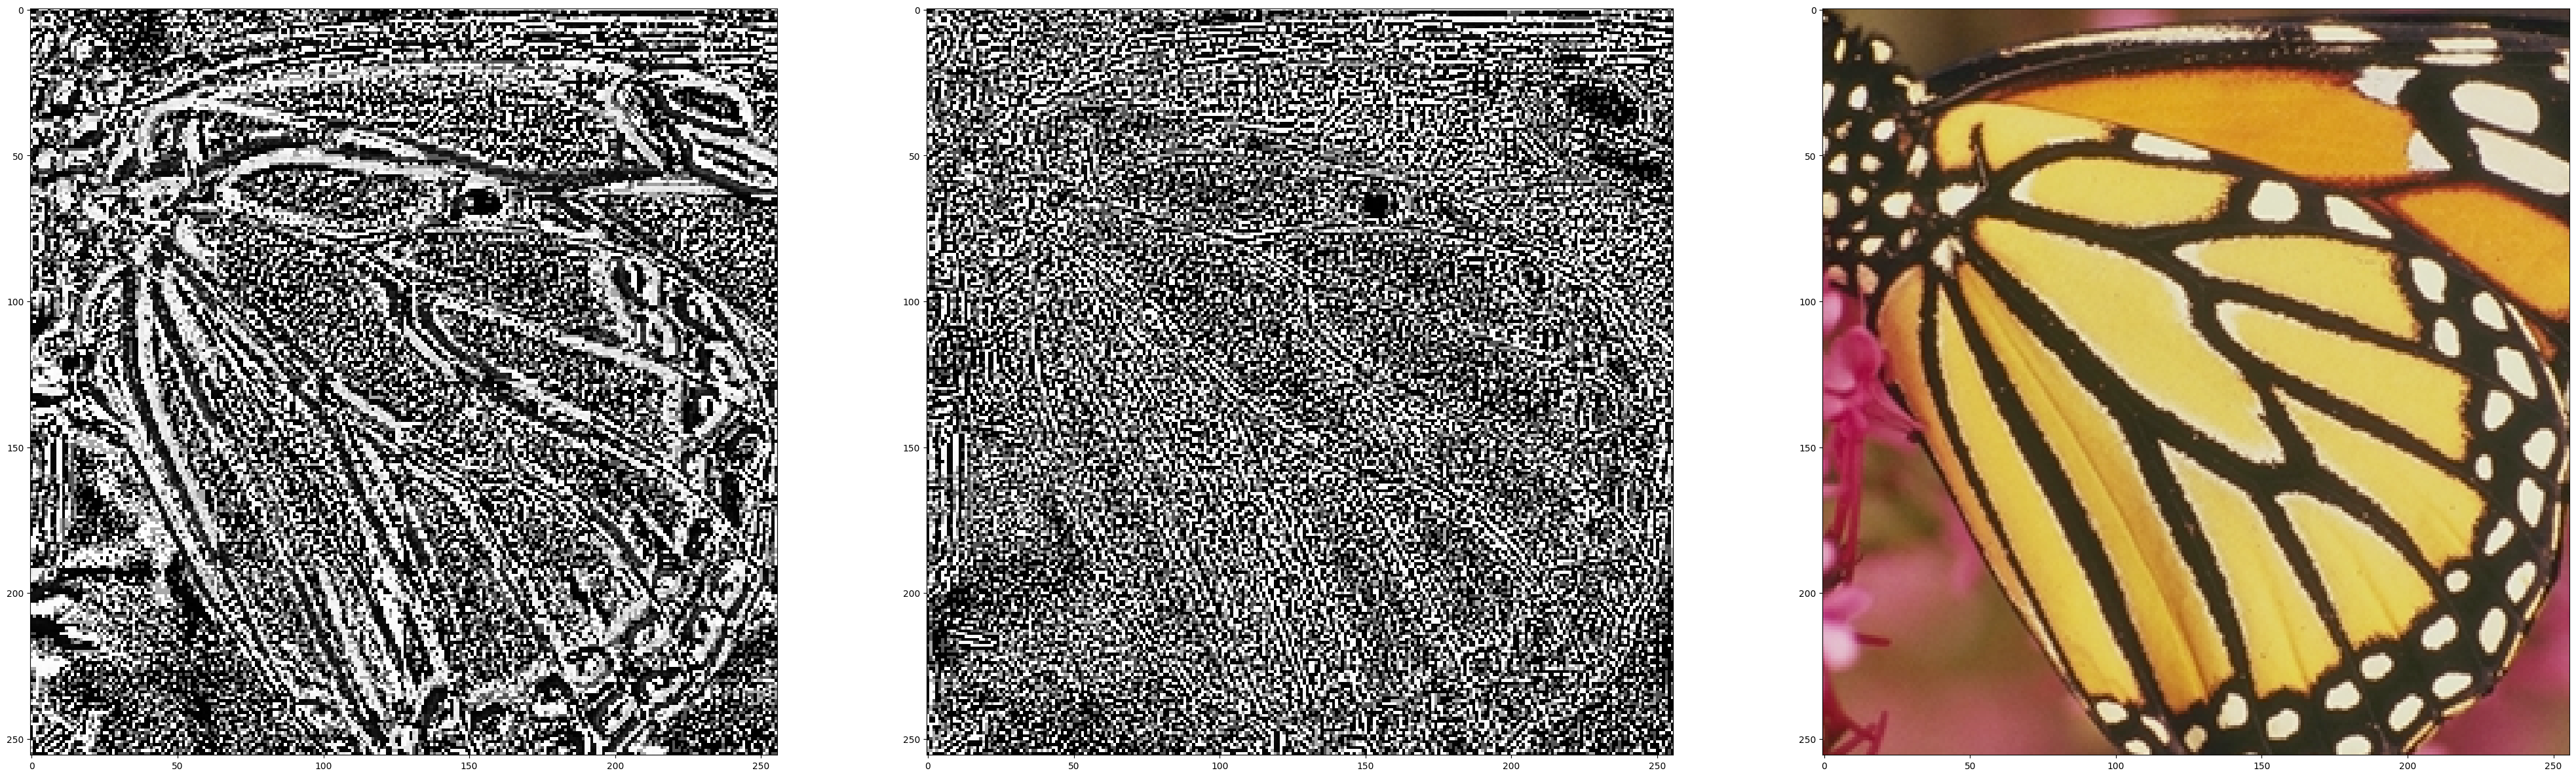

In [106]:
#残差差异：

plt.figure(figsize=(50,150))
plt.subplot(1,3,1)
plt.imshow(np.mean(tensor2img(gt)-tensor2img(sr), axis=2), cmap='grey')
plt.subplot(1,3,2)
plt.imshow(np.mean(tensor2img(gt)-sr_swin_s, axis=2), cmap='grey')
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(tensor2img(gt), cv2.COLOR_BGR2RGB))

In [125]:
red = np.concat([np.ones([256,256,1]),np.zeros([256,256,2])], axis=2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.472549019607843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4797385620915031].


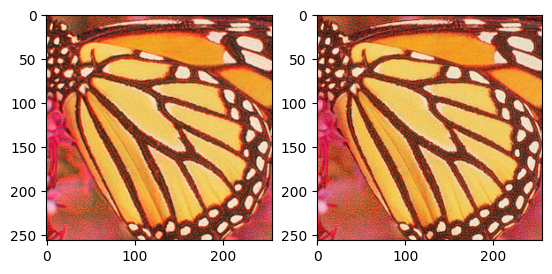

In [142]:
error_map_sr = np.mean(tensor2img(gt)-tensor2img(sr), axis=2)/255
error_map_sr_swin_s = np.mean(tensor2img(gt)-sr_swin_s, axis=2)/255
plt.subplot(1,2,1)
plt.imshow(np.array([error_map_sr]*3).transpose(1,2,0)*red*0.5+cv2.cvtColor(tensor2img(gt), cv2.COLOR_BGR2RGB)*1/255)
plt.subplot(1,2,2)
plt.imshow(np.array([error_map_sr_swin_s]*3).transpose(1,2,0)*red*0.5+cv2.cvtColor(tensor2img(gt), cv2.COLOR_BGR2RGB)*1/255)

In [150]:
a = torch.zeros(1,3,20,20)
b = torch.ones(1,3,20,20)
sum([a,b])/2

tensor([[[[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          ...,
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000]],

         [[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          ...,
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000]],

         [[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0